**Explicit vs Implicit — 1D Heat Equation**

finite difference descretizations for ∂T/∂t = α ∂²T/∂x²

discretize on uniform grid: xᵢ = i·Δx, tⁿ = n·Δt, with Tᵢⁿ ≈ T(xᵢ, tⁿ)

second spatial derivative:

∂²T/∂x² ≈ [ T[i+1] − 2·T[i] + T[i-1] ] / (Δx)²

I am going to compare when to evaluate this: whether at time n (explicit) or n+1 (implicit)

**Explicit**

[ T[i]^(n+1) − T[i]^n ] / Δt = α · [ T[i+1]^n − 2T[i]^n + T[i-1]^n ] / (Δx)²

Let λ = α·Δt/(Δx)²

So then:
T[i]^(n+1) = r·T[i+1]^n + (1−2r)·T[i]^n + r·T[i-1]^n

This is conditionally stable for when λ <= 1/2. So Δt <= (Δx)²/(2α)

**Implicit**

[ T[i]^(n+1) − T[i]^n ] / Δt = α · [ T[i+1]^(n+1) − 2T[i]^(n+1) + T[i-1]^(n+1) ] / (Δx)²

−λ·T[i-1]^(n+1) + (1+2λ)·T[i]^(n+1) − λ·T[i+1]^(n+1) = T[i]^n

This will always be stable

going to attempt to see different lambdas and how they effect both explicit and implicit

In [5]:
import numpy as np
from scipy.linalg import solve_banded
import matplotlib.pyplot as plt

N = 201
x = np.linspace(-1, 1, N)
dx = 1 / 200

alpha = 0.005
l = 0.4  # CFL number (lambda)
dt = l * dx**2 / alpha

x = jnp.linspace(-1, 1, N)
T_0 = jnp.exp(-(x + 0.5)**2 / 0.001)[jnp.newaxis, :]

n_steps = N  # number of timesteps


def solve_explicit(T_init, l, n_steps):
    T = T_init.copy()
    for _ in range(n_steps):
        T_new = T.copy()
        T_new[1:-1] = T[1:-1] + l * (T[2:] - 2*T[1:-1] + T[:-2])
        T_new[0] = 0
        T_new[-1] = 0
        T = T_new
    return T

def build_tridiag(n, r):
    ab = np.zeros((3, n))
    ab[0, 1:]  = -r
    ab[1, :]   =  1 + 2*r
    ab[2, :-1] = -r
    return ab

def solve_implicit(T_init, l, n_steps):
    T = T_init.copy()
    n_int = len(T) - 2  # interior nodes
    ab = build_tridiag(n_int, l)
    for _ in range(n_steps):
        b = T[1:-1].copy()
        b[0]  += l * T[0]
        b[-1] += l * T[-1]
        T[1:-1] = solve_banded((1, 1), ab, b)
        T[0] = 0
        T[-1] = 0
    return T

import jax
import jax.numpy as jnp
from jax import lax
from functools import partial

jax.config.update("jax_enable_x64", True)

def _build_tridiag(n, r):
    """Build the tridiagonal matrix for the implicit scheme."""
    main = (1 + 2 * r) * jnp.ones(n)
    off = -r * jnp.ones(n - 1)
    return jnp.diag(main) + jnp.diag(off, 1) + jnp.diag(off, -1)

@partial(jax.jit, static_argnames=("num_time_steps",))
def _solve_inner(T_interior, tridag, r, T_left, T_right, num_time_steps):
    """Solve the implicit scheme for one time step."""
    def _step(T, _):
        b = T.at[0].add(r * T_left)
        b = b.at[-1].add(r * T_right)
        return jnp.linalg.solve(tridag, b), None
    
    T_final, _ = lax.scan(_step, T_interior, None, length=num_time_steps)
    return T_final

def solve(T0, alpha, dt, t_final, domain_length=2.0):
    """Solve 1D heat equation using implicit scheme"""
    T0 = jnp.asarray(T0, dtype=jnp.float64)
    n = T0.shape[1]
    dx = domain_length / (n - 1)
    r = alpha * dt / dx**2
    num_time_steps  = int(round(t_final / dt))
    tridag = _build_tridiag(n - 2, r)

    T_interior = T0[0, 1:-1]
    T_final_interior = _solve_inner(T_interior, tridag, r, T0[0, 0], T0[0, -1], num_time_steps)
    T_final = jnp.concatenate([T0[0, :1], T_final_interior, T0[0, -1:]])
    return T_final[jnp.newaxis, :]

In [14]:
T_imp = solve(T_0, 0.006, dt, 1.0)
T_imp_1 = solve(T_0, 0.004, dt, 1.0)



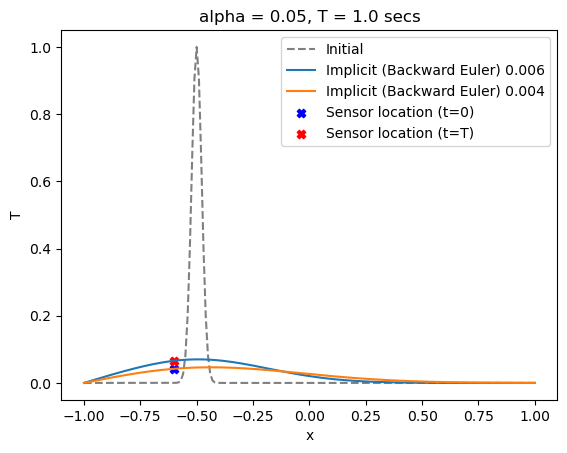

In [ ]:
import matplotlib.pyplot as plt
plt.plot(x, T_0[0],   label='Initial',  linestyle='--', color='gray')
plt.plot(x, T_imp[0], label='Implicit (Backward Euler) 0.006')
plt.plot(x, T_imp_1[0], label='Implicit (Backward Euler) 0.004')


plt.scatter(x[int(N // 5)], T_0[0][int(N // 5)], c="b", marker="X", label='Sensor location (t=0)')
plt.scatter(x[int(N // 5)], T_imp[0][int(N // 5)], c="r", marker="X", label='Sensor location (t=T)')

plt.xlabel('x')
plt.ylabel('T')
plt.title(f'alpha = 0.05, T = 1.0 secs')
plt.legend()
plt.show()

NameError: name 'animation' is not defined

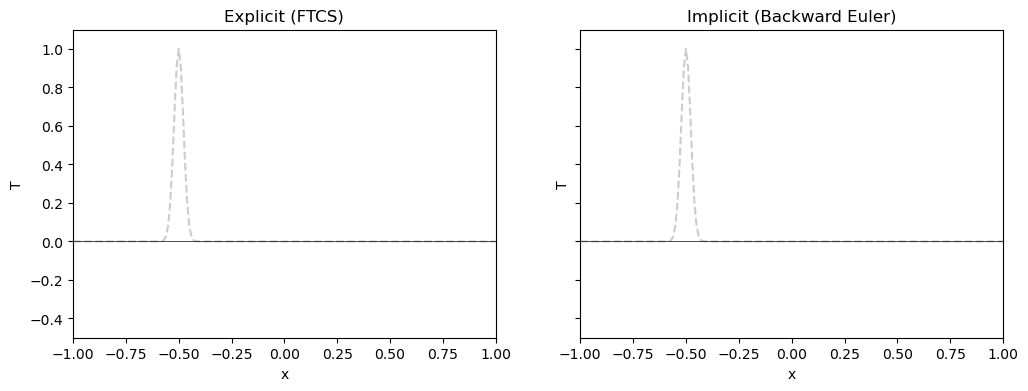

In [4]:
lambdas = np.linspace(0.1, 1.0, 60) 

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle('')

for ax, label in zip(axes, ['Explicit (FTCS)', 'Implicit (Backward Euler)']):
    ax.set_xlim(-1, 1)
    ax.set_ylim(-0.5, 1.1)
    ax.set_xlabel('x')
    ax.set_ylabel('T')
    ax.set_title(label)
    ax.plot(x, T_0, '--', color='gray', alpha=0.4, label='Initial')
    ax.axhline(0, color='black', linewidth=0.5)

line_exp, = axes[0].plot([], [], color='steelblue', lw=2)
line_imp, = axes[1].plot([], [], color='orange', lw=2)
title = fig.suptitle('')

def update(frame):
    l = lambdas[frame]
    
    # clamp explicit if it blows up
    T_exp = solve_explicit(T_0, l, n_steps)
    T_exp_plot = np.clip(T_exp, -0.5, 1.1)
    
    T_imp = solve_implicit(T_0, l, n_steps)
    
    line_exp.set_data(x, T_exp_plot)
    line_imp.set_data(x, T_imp)
    title.set_text(f'λ = {l:.2f}  {"UNSTABLE" if l > 0.5 else ""}')
    return line_exp, line_imp, title

ani = animation.FuncAnimation(fig, update, frames=len(lambdas), interval=100, blit=True)
plt.tight_layout()
ani.save('heat_lambda.gif', writer='pillow', fps=10)
plt.show()

**Using JAX Implicit Solver**

In [4]:
from implicit_solver import solve
import jax
import jax.numpy as jnp
from jax import lax
from functools import partial

N     = 201
alpha = 0.01
l     = 0.4                      # CFL number
dx    = 2 / (N - 1)              # domain is [-1, 1], length 2
dt    = l * dx**2 / alpha
n_steps = N
t_final = n_steps * dt 

x   = jnp.linspace(-1, 1, N)
T_0 = jnp.exp(-(x + 0.5)**2 / 0.001)[jnp.newaxis, :]

T_f = solve(T_0, alpha, dt, t_final)

print(f"T_0 shape : {T_0.shape}")
print(f"T_f shape : {T_f.shape}")
print(f"r         : {l}")
print(f"dt        : {dt:.6f}")
print(f"t_final   : {t_final:.4f}")

dL_dalpha = jax.grad(
    lambda a: jnp.sum(solve(T_0, a, dt, t_final)**2)
)(alpha)
print(f"∂loss/∂alpha: {dL_dalpha:.4f}")

T_0 shape : (1, 201)
T_f shape : (1, 201)
r         : 0.4
dt        : 0.004000
t_final   : 0.8040
∂loss/∂alpha: -33.4373


compare with analystical solutins